<a href="https://colab.research.google.com/github/gugulothusrivallika-collab/Task-1/blob/main/Task%201.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Preview:

                                    review sentiment
0                  This product is amazing  positive
1                        I love this phone  positive
2  Excellent quality and great performance  positive
3             Very happy with the purchase  positive
4                     Best experience ever  positive

Model Accuracy:
0.5

Classification Report:

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
    positive       0.50      1.00      0.67         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


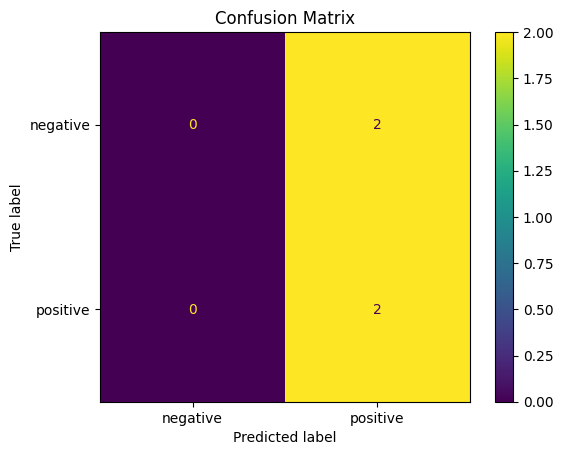


Custom Review Prediction:
Review: This product quality is excellent
Sentiment: positive

Custom Review Prediction:
Review: This is the worst purchase I made
Sentiment: positive


In [49]:
# ============================================
# CODTECH Internship Task-2
# Sentiment Analysis with NLP
# TF-IDF + Logistic Regression
# ============================================

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ============================================
# Step 2: Create Dataset
# ============================================

data = {
    "review": [
        "This product is amazing",
        "I love this phone",
        "Excellent quality and great performance",
        "Very happy with the purchase",
        "Best experience ever",
        "Absolutely fantastic",
        "Highly recommended product",
        "The service was wonderful",
        "I am very satisfied",
        "Superb and outstanding",

        "Worst product I have bought",
        "Very disappointing experience",
        "I hate this item",
        "Poor quality and bad performance",
        "Not worth the money",
        "Terrible customer service",
        "Completely useless",
        "I am unhappy with this purchase",
        "Awful and frustrating",
        "Waste of money"
    ],

    "sentiment": [
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",
        "positive",

        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative",
        "negative"
    ]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Display first 5 rows
print("Dataset Preview:\n")
print(df.head())

# ============================================
# Step 3: Split Dataset
# ============================================

X = df["review"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# ============================================
# Step 4: TF-IDF Vectorization
# ============================================

tfidf = TfidfVectorizer(stop_words='english')

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# ============================================
# Step 5: Train Logistic Regression Model
# ============================================

model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

# ============================================
# Step 6: Predictions
# ============================================

y_pred = model.predict(X_test_tfidf)

# ============================================
# Step 7: Model Evaluation
# ============================================

accuracy = accuracy_score(y_test, y_pred)

print("\nModel Accuracy:")
print(accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ============================================
# Step 8: Confusion Matrix
# ============================================

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ============================================
# Step 9: Test Custom Review
# ============================================

sample_review = ["This product quality is excellent"]

sample_tfidf = tfidf.transform(sample_review)

prediction = model.predict(sample_tfidf)

print("\nCustom Review Prediction:")
print("Review:", sample_review[0])
print("Sentiment:", prediction[0])

# ============================================
# Step 10: Another Custom Review
# ============================================

sample_review2 = ["This is the worst purchase I made"]

sample_tfidf2 = tfidf.transform(sample_review2)

prediction2 = model.predict(sample_tfidf2)

print("\nCustom Review Prediction:")
print("Review:", sample_review2[0])
print("Sentiment:", prediction2[0])

# ============================================
# END OF PROJECT
# ============================================